# অলীকবচন — Bengali LLM Hallucination Detection

**Task**: given a Bengali prompt (`prompt_bn`) and a candidate LLM response (`response_bn`),
optionally grounded in a `context` passage, predict `label = 1` (faithful) or `label = 0`
(hallucinated). **Metric**: binary F1 on the *hallucinated* class (label = 0).

## Architecture (hybrid regime pipeline)

```
data -> leakage audit / EDA
     -> regime router (context_grounding | factual_qa | math_numeric | translation_summarization)
     -> feature extraction
          - lexical: token overlap, length stats, Bengali-numeral-aware number support
          - LaBSE embeddings: prompt/response/context similarity
          - RAG: cross-lingual retrieval over a Bangladesh-history book corpus (C1 band evidence)
          - NLI (mDeBERTa-v3-xnli): entailment/contradiction of response vs evidence
          - char-TFIDF + LogisticRegression out-of-fold probability
          - LLM judge (Qwen2.5-Instruct): P("হ্যাঁ") vs P("না") from first-token logits
     -> LightGBM / LogisticRegression meta-classifier (OOF cross-validation)
     -> threshold tuned on OOF to maximize F1(hallucinated)
     -> uncertainty band deferral to LLM judge (kept only if it improves OOF F1)
     -> submission.csv
```

All models are open-weight and run locally in this notebook (no external APIs), per the
competition rules. Total model footprint << 50 GB; runtime well under the 9 h limit on T4x2.


In [3]:
# ============================================================
# Setup: environment detection, paths, configuration
# ============================================================
import importlib, subprocess, sys
for mod, pkg in [("pypdf", "pypdf"), ("lightgbm", "lightgbm"),
                 ("sentence_transformers", "sentence-transformers"),
                 ("accelerate", "accelerate")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, re, gc, json, glob, time, warnings
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
T0 = time.time()

def stamp(msg):
    print(f"[{time.time()-T0:7.1f}s] {msg}", flush=True)

ON_KAGGLE = os.path.exists("/kaggle/input")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FP16 = DEVICE == "cuda"

def _find_comp_dir():
    cands = [
        os.environ.get("BH_DATA_DIR", ""),
        "/kaggle/input/bengali-hallucination",
        "/kaggle/input/competitions/bengali-hallucination",
    ]
    cands = [c for c in cands if c]
    for c in cands:
        if os.path.isdir(c):
            return c
    for c in sorted(glob.glob("/kaggle/input/*")):
        if "hallucination" in os.path.basename(c).lower():
            return c
    return "./dev_data"  # local development fallback

COMP_DIR = _find_comp_dir()

def _find_file(substr, ext):
    hits = [f for f in sorted(glob.glob(os.path.join(COMP_DIR, "*" + ext)))
            if substr in os.path.basename(f).lower()]
    return hits[0] if hits else None

TRAIN_JSON = _find_file("sample", ".json") or _find_file("", ".json")
TEST_CSV = _find_file("test", ".csv")
SAMPLE_SUB = _find_file("submission", ".csv")

def _find_books_dir():
    for c in ["/kaggle/input/bengali-historical-books", "./data"]:
        if os.path.isdir(c) and glob.glob(os.path.join(c, "*.pdf")):
            return c
    return None

BOOKS_DIR = _find_books_dir()

# Full-size models on Kaggle GPU; small stand-ins for local CPU smoke tests.
NLI_MODEL_NAME = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"
EMB_MODEL_NAME = ("sentence-transformers/LaBSE" if ON_KAGGLE
                  else "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
LLM_CANDIDATES = (["Qwen/Qwen2.5-7B-Instruct", "Qwen/Qwen2.5-3B-Instruct",
                   "Qwen/Qwen2.5-1.5B-Instruct"]
                  if ON_KAGGLE else ["Qwen/Qwen2.5-0.5B-Instruct"])

print(f"ON_KAGGLE={ON_KAGGLE}  DEVICE={DEVICE}")
print(f"COMP_DIR   = {COMP_DIR}")
print(f"TRAIN_JSON = {TRAIN_JSON}")
print(f"TEST_CSV   = {TEST_CSV}")
print(f"SAMPLE_SUB = {SAMPLE_SUB}")
print(f"BOOKS_DIR  = {BOOKS_DIR}")


ON_KAGGLE=True  DEVICE=cpu
COMP_DIR   = /kaggle/input/competitions/bengali-hallucination
TRAIN_JSON = /kaggle/input/competitions/bengali-hallucination/dataset samples.json
TEST_CSV   = /kaggle/input/competitions/bengali-hallucination/test set.csv
SAMPLE_SUB = /kaggle/input/competitions/bengali-hallucination/sample submission.csv
BOOKS_DIR  = None


## Stage 0 — Load and normalize the data

Schema (per the official starter notebook): `prompt_bn`, `response_bn`, `context`, `label`.
The `context` column uses several stand-ins for "no context" (missing value, empty string,
`"nan"`, the literal `"[NULL]"`) — all normalized to `""`. Purely numeric responses load
from JSON as ints, so both text fields are coerced to `str`.

In [4]:
NO_CONTEXT_VALUES = {"", "nan", "none", "null", "[null]"}

def clean_context(value):
    if pd.isna(value):
        return ""
    s = str(value).strip()
    return "" if s.lower() in NO_CONTEXT_VALUES else s

def normalize_frame(df, is_train):
    df = df.copy()
    ren = {}
    for c in df.columns:  # tolerate minor column-name drift between splits
        lc = c.strip().lower()
        if lc in ("prompt", "prompt_bn"):
            ren[c] = "prompt_bn"
        elif lc in ("response", "response_bn"):
            ren[c] = "response_bn"
        elif lc in ("context", "label", "id"):
            ren[c] = lc
    df = df.rename(columns=ren)
    if "id" not in df.columns:
        df["id"] = np.arange(len(df))
    if "context" not in df.columns:
        df["context"] = ""
    for col in ("prompt_bn", "response_bn"):
        df[col] = df[col].astype(str)
    df["context"] = df["context"].apply(clean_context)
    df["has_context"] = (df["context"].str.len() > 0).astype(int)
    if is_train:
        df["label"] = df["label"].astype(int)
    return df.reset_index(drop=True)

with open(TRAIN_JSON, encoding="utf-8") as f:
    train_df = normalize_frame(pd.DataFrame(json.load(f)), is_train=True)

if TEST_CSV:
    test_df = normalize_frame(pd.read_csv(TEST_CSV), is_train=False)
else:
    print("WARNING: no test csv found — using a small slice of train as a stand-in")
    test_df = train_df.drop(columns=["label"]).head(5).copy()

stamp(f"loaded train={len(train_df)}  test={len(test_df)}")
print("train columns:", train_df.columns.tolist())
extra_cols = [c for c in train_df.columns
              if c not in {"id", "prompt_bn", "response_bn", "context", "label", "has_context"}]
print("extra columns:", extra_cols)
train_df.head(3)


[    0.1s] loaded train=299  test=2516
train columns: ['context', 'prompt_bn', 'response_bn', 'label', 'id', 'has_context']
extra columns: []


,context,prompt_bn,response_bn,label,id,has_context
0,উইন্ডোজে ইউনিকোড ভিত্তিক বাংলা লেখার জন্য ২০০৩...,অভ্র কিবোর্ড কে উদ্ভাবন করেন ?,মেহদী হাসান খান,1,0,1
1,,"""ধান্ধা"" এর ভাবার্থ কী?",কোন অসৎ উদ্দেশ্য,1,1,0
2,,‘কাঁঠালপাড়া’য় জন্মগ্রহণ করেন কোন লেখক?,শরৎচন্দ্র চট্টোপাধ্যায়,0,2,0


## Stage 0 — EDA + leakage audit

Label balance (1 = faithful, 0 = hallucinated):
label
1    0.545
0    0.455
Name: proportion, dtype: float64

Context coverage:
has_context
0    169
1    130
Name: count, dtype: int64

Label balance by context presence:
label            0      1
has_context              
0            0.527  0.473
1            0.362  0.638


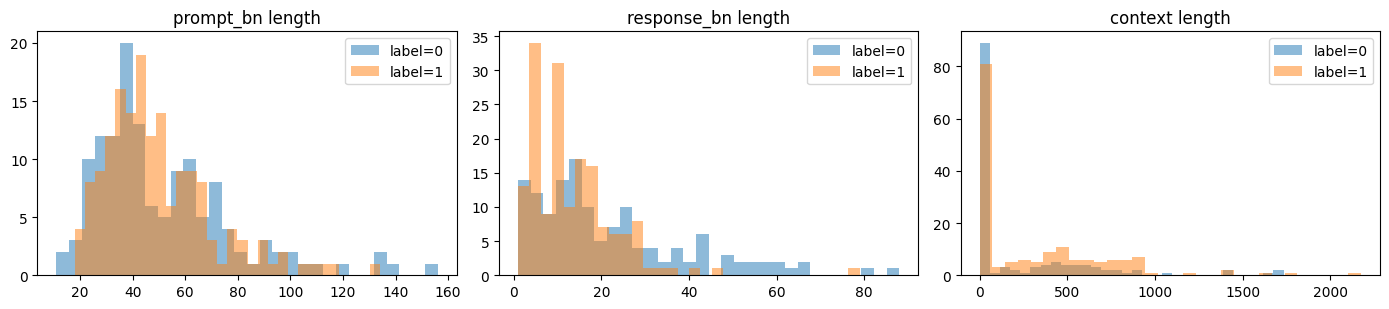

In [5]:
print("Label balance (1 = faithful, 0 = hallucinated):")
print(train_df["label"].value_counts(normalize=True).round(3))
print()
print("Context coverage:")
print(train_df["has_context"].value_counts())
print()
print("Label balance by context presence:")
print(train_df.groupby("has_context")["label"].value_counts(normalize=True).unstack().round(3))
for c in extra_cols:  # any band / domain metadata the organizers included
    if train_df[c].nunique() <= 30:
        print(f"\n--- {c} ---")
        print(train_df.groupby(c)["label"].agg(["count", "mean"]).round(3))

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
    for ax, col in zip(axes, ["prompt_bn", "response_bn", "context"]):
        for lab, sub in train_df.groupby("label"):
            ax.hist(sub[col].str.len(), bins=30, alpha=0.5, label=f"label={lab}")
        ax.set_title(f"{col} length")
        ax.legend()
    plt.tight_layout(); plt.show()
except Exception as e:
    print("plot skipped:", e)


In [6]:
# Leakage audit: duplicate ids and exact train/test (prompt, response) matches.
# An exact match to a labeled sample row lets us copy the known label directly.
def norm_key(p, r):
    return re.sub(r"\s+", " ", str(p).strip().lower()) + " || " + re.sub(r"\s+", " ", str(r).strip().lower())

print("duplicate ids in train:", train_df["id"].duplicated().sum())
print("duplicate ids in test :", test_df["id"].duplicated().sum())

train_keys = {norm_key(p, r): int(l) for p, r, l in
              zip(train_df["prompt_bn"], train_df["response_bn"], train_df["label"])}
test_df["leak_label"] = [train_keys.get(norm_key(p, r), np.nan)
                         for p, r in zip(test_df["prompt_bn"], test_df["response_bn"])]
stamp(f"exact train->test matches: {test_df['leak_label'].notna().sum()}")


duplicate ids in train: 0
duplicate ids in test : 0
[    1.0s] exact train->test matches: 11


## Stage 1 — Regime router + lexical features

Each sample is routed to the regime that determines which verification signals apply:

| regime | signal |
|---|---|
| `context_grounding` | a source passage is present -> NLI vs context |
| `math_numeric` | numbers in prompt & response -> number-support check |
| `translation_summarization` | translate/summarize instruction -> semantic similarity |
| `factual_qa` | closed-book fact claim -> retrieval + NLI + LLM knowledge |

Bengali numerals (০-৯) are normalized to ASCII before any numeric matching.

In [7]:
BN2EN_DIGITS = str.maketrans("০১২৩৪৫৬৭৮৯", "0123456789")
# NB: deliberately NOT matching bare "বাংলায়" ("in Bengali") — it appears in ordinary
# factual prompts ("বাংলায় লেখো...") and would over-route them to translation.
TRANSLATE_PAT = re.compile(
    r"অনুবাদ|translate|ইংরেজিতে|বাংলায় অনুবাদ|ইংরেজি থেকে|"
    r"paraphrase|রূপান্তর|সরল করো|সরল ভাষায়", re.I)
SUMMARY_PAT = re.compile(
    r"সারাংশ|সারসংক্ষেপ|সংক্ষেপে|summar|মূল বিষয়|key points|সংক্ষিপ্ত", re.I)
NUM_PAT = re.compile(r"\d+(?:\.\d+)?")

def bn_tokens(text):
    return re.findall(r"[ঀ-৿\w]+", str(text).lower())

def extract_numbers(text):
    return set(NUM_PAT.findall(str(text).translate(BN2EN_DIGITS)))

def route(row):
    if row["has_context"]:
        return "context_grounding"
    p = row["prompt_bn"]
    if TRANSLATE_PAT.search(p) or SUMMARY_PAT.search(p):
        return "translation_summarization"
    if extract_numbers(row["response_bn"]) and extract_numbers(p):
        return "math_numeric"
    return "factual_qa"

def token_overlap(resp, src):
    rt = set(bn_tokens(resp))
    if not rt:
        return 0.0
    return len(rt & set(bn_tokens(src))) / len(rt)

def number_support(row):
    # fraction of numbers in the response that also appear in prompt+context;
    # -1 = response contains no numbers (not applicable)
    nums = extract_numbers(row["response_bn"])
    if not nums:
        return -1.0
    src = extract_numbers(row["prompt_bn"] + " " + row["context"])
    return len(nums & src) / len(nums)

def repetition_score(text):
    # hallucinated generations often loop; high = repetitive = suspicious
    words = bn_tokens(text)
    if len(words) < 4:
        return 0.0
    return 1.0 - len(set(words)) / len(words)

def rouge_l_f(ref, hyp, cap=300):
    # dependency-free ROUGE-L F1 on Bengali-aware tokens (LCS, O(n*m), capped)
    a, b = bn_tokens(ref)[:cap], bn_tokens(hyp)[:cap]
    if not a or not b:
        return 0.0
    dp = [0] * (len(b) + 1)
    for x in a:
        prev = 0
        for j, yb in enumerate(b, 1):
            cur = dp[j]
            dp[j] = prev + 1 if x == yb else max(dp[j], dp[j - 1])
            prev = cur
    lcs = dp[-1]
    p, r = lcs / len(b), lcs / len(a)
    return 0.0 if p + r == 0 else 2 * p * r / (p + r)

REGIMES = ["context_grounding", "factual_qa", "math_numeric", "translation_summarization"]

def add_basic_features(df):
    df["regime"] = df.apply(route, axis=1)
    df["log_resp_len"] = np.log1p(df["response_bn"].str.len())
    df["log_prompt_len"] = np.log1p(df["prompt_bn"].str.len())
    df["log_ctx_len"] = np.log1p(df["context"].str.len())
    df["resp_ctx_len_ratio"] = df["response_bn"].str.len() / (df["context"].str.len() + 1)
    df["tok_overlap_ctx"] = [token_overlap(r, c) if h else np.nan
                             for r, c, h in zip(df["response_bn"], df["context"], df["has_context"])]
    df["tok_overlap_prompt"] = [token_overlap(r, p)
                                for r, p in zip(df["response_bn"], df["prompt_bn"])]
    df["number_support"] = df.apply(number_support, axis=1)
    df["n_numbers_resp"] = df["response_bn"].map(lambda t: len(extract_numbers(t)))
    df["repetition"] = df["response_bn"].map(repetition_score)
    df["rouge_l"] = [rouge_l_f(p, r) if reg == "translation_summarization" else np.nan
                     for p, r, reg in zip(df["prompt_bn"], df["response_bn"], df["regime"])]
    # real-data EDA: responses are mostly short answers ("রানওয়ে", "৪৭", "ক)") —
    # exact-presence of the (normalized) answer inside the context is a strong signal,
    # and MCQ prompts (ক) খ) গ) ...) behave differently from free-form QA
    def _norm(t):
        return re.sub(r"[^ঀ-৿\w]", "", str(t).lower().translate(BN2EN_DIGITS))
    df["resp_in_ctx"] = [(1.0 if _norm(r) and _norm(r) in _norm(c) else 0.0) if h else np.nan
                         for r, c, h in zip(df["response_bn"], df["context"], df["has_context"])]
    df["is_mcq"] = (df["prompt_bn"].str.contains(r"ক\)", regex=True)
                    & df["prompt_bn"].str.contains(r"খ\)", regex=True)).astype(int)
    # cultural-band metadata, if the organizers included it (metric tie-breaks on C1)
    band_col = next((c for c in df.columns if "band" in c.lower()), None)
    if band_col:
        vals = df[band_col].astype(str).str.upper()
        df["is_c1"] = vals.str.contains("C1").astype(int)
        df["is_c2"] = vals.str.contains("C2").astype(int)
    for reg in REGIMES:
        df[f"regime_{reg}"] = (df["regime"] == reg).astype(int)
    return df

train_df = add_basic_features(train_df)
test_df = add_basic_features(test_df)
print(train_df["regime"].value_counts())
if "label" in train_df:
    print()
    print(pd.crosstab(train_df["regime"], train_df["label"], normalize="index").round(3))
stamp("router + lexical features done")


regime
factual_qa           149
context_grounding    130
math_numeric          20
Name: count, dtype: int64

label                  0      1
regime                         
context_grounding  0.362  0.638
factual_qa         0.517  0.483
math_numeric       0.600  0.400
[    1.5s] router + lexical features done


## Stage 2a — Multilingual embeddings + cross-lingual RAG evidence

LaBSE embeds Bengali and English into one space, giving:
- `cos_prompt_resp`, `cos_ctx_resp` similarity features (translation/summarization signal),
- cross-lingual retrieval from a Bangladesh-history book corpus (10 PDFs) so closed-book
  C1 (Bangladesh-specific) claims get textual evidence, which the NLI stage then scores.

In [8]:
from sentence_transformers import SentenceTransformer

stamp(f"loading embedding model: {EMB_MODEL_NAME}")
emb_model = SentenceTransformer(EMB_MODEL_NAME, device=DEVICE)

def embed(texts, bs=64):
    return emb_model.encode([str(t)[:1500] for t in texts], batch_size=bs,
                            convert_to_numpy=True, normalize_embeddings=True,
                            show_progress_bar=False)

def add_sim_features(df):
    ep = embed(df["prompt_bn"].tolist())
    er = embed(df["response_bn"].tolist())
    df["cos_prompt_resp"] = (ep * er).sum(axis=1)
    df["cos_ctx_resp"] = np.nan
    mask = df["has_context"].astype(bool).values
    if mask.any():
        ec = embed(df.loc[mask, "context"].tolist())
        df.loc[mask, "cos_ctx_resp"] = (ec * er[mask]).sum(axis=1)
    return df

train_df = add_sim_features(train_df)
test_df = add_sim_features(test_df)
stamp("similarity features done")

def chunk_text(t, size=900, overlap=120):
    t = re.sub(r"\s+", " ", str(t)).strip()
    if not t:
        return []
    out, step = [], size - overlap
    for i in range(0, max(len(t) - overlap, 1), step):
        out.append(t[i:i + size])
    return out

book_chunks = []
if BOOKS_DIR:
    from pypdf import PdfReader
    for pdf_path in sorted(glob.glob(os.path.join(BOOKS_DIR, "*.pdf"))):
        try:
            reader = PdfReader(pdf_path)
            text = "\n".join((page.extract_text() or "") for page in reader.pages)
            book_chunks += chunk_text(text)
        except Exception as e:
            print("skipping", os.path.basename(pdf_path), "->", e)
book_chunks = [c for c in book_chunks if len(c) > 250]
if not ON_KAGGLE:
    book_chunks = book_chunks[:300]  # keep local CPU smoke test fast
stamp(f"book corpus: {len(book_chunks)} chunks")

# minimum cross-lingual cosine for a chunk to count as evidence. Bengali query vs
# English book text sits lower than same-language similarity, so this is looser than
# a monolingual cutoff would be — tune against real data once available.
RETR_MIN_SIM = 0.30

def add_retrieval_evidence(df, k=5):
    # evidence = provided context when present, else top-k retrieved book chunks
    # that clear RETR_MIN_SIM (irrelevant chunks would feed the NLI false signals)
    df["evidence"] = df["context"]
    df["retr_sim_max"] = np.nan
    df["retr_sim_mean"] = np.nan
    mask = ~df["has_context"].astype(bool)
    if not mask.any() or not book_chunks:
        return df
    queries = (df.loc[mask, "prompt_bn"] + " " + df.loc[mask, "response_bn"]).tolist()
    sims = embed(queries) @ chunk_emb.T
    top = np.argsort(-sims, axis=1)[:, :k]
    ev, smax, smean = [], [], []
    for i in range(top.shape[0]):
        s = sims[i, top[i]]
        keep = [j for j, sv in zip(top[i], s) if sv >= RETR_MIN_SIM]
        ev.append(" ".join(book_chunks[j] for j in keep))  # "" if nothing relevant
        smax.append(float(s.max()))
        smean.append(float(s.mean()))
    df.loc[mask, "evidence"] = ev
    df.loc[mask, "retr_sim_max"] = smax
    df.loc[mask, "retr_sim_mean"] = smean
    n_kept = sum(1 for e in ev if e)
    print(f"retrieval: {n_kept}/{len(ev)} closed-book rows got evidence above {RETR_MIN_SIM}")
    return df

if book_chunks:
    chunk_emb = embed(book_chunks, bs=128)
train_df = add_retrieval_evidence(train_df)
test_df = add_retrieval_evidence(test_df)
stamp("retrieval evidence done")

del emb_model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()


[    1.5s] loading embedding model: sentence-transformers/LaBSE


'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/sentence-transformers/LaBSE/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/sentence-transformers/LaBSE/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


RuntimeError: Cannot send a request, as the client has been closed.

## Stage 2a½ — (optional) BanglaBERT encoder for closed-book rows

Targeted monolingual encoder for the C1 band: mean-pooled BanglaBERT similarity between
prompt and response, computed **only** on `factual_qa` rows. Off by default — enable for
its own ablation submission so its effect on the leaderboard is measurable in isolation.

In [ ]:
ENABLE_BANGLABERT = False  # flip for a dedicated ablation submission

if ENABLE_BANGLABERT:
    from transformers import AutoModel, AutoTokenizer as _AT
    stamp("loading BanglaBERT (csebuetnlp/banglabert)")
    bb_tok = _AT.from_pretrained("csebuetnlp/banglabert")
    bb_model = AutoModel.from_pretrained("csebuetnlp/banglabert").to(DEVICE).eval()

    @torch.no_grad()
    def bb_embed(texts, bs=32):
        out = []
        for i in range(0, len(texts), bs):
            enc = bb_tok([str(t)[:512] for t in texts[i:i + bs]], truncation=True,
                         max_length=256, padding=True, return_tensors="pt").to(DEVICE)
            h = bb_model(**enc).last_hidden_state
            m = enc["attention_mask"].unsqueeze(-1)
            emb = (h * m).sum(1) / m.sum(1).clamp(min=1)
            out.append(torch.nn.functional.normalize(emb, dim=-1).cpu().numpy())
        return np.vstack(out)

    for df in (train_df, test_df):
        df["bb_cos_pr"] = np.nan
        m = (df["regime"] == "factual_qa").values
        if m.any():
            ep = bb_embed(df.loc[m, "prompt_bn"].tolist())
            er = bb_embed(df.loc[m, "response_bn"].tolist())
            df.loc[m, "bb_cos_pr"] = (ep * er).sum(axis=1)
    del bb_model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    stamp("BanglaBERT features done")
else:
    print("BanglaBERT disabled (ENABLE_BANGLABERT=False)")


## Stage 2b — NLI entailment/contradiction features

`mDeBERTa-v3-base-xnli-multilingual-nli-2mil7` scores (premise, hypothesis) pairs in 100+
languages, including Bengali–English cross-lingual pairs. Long premises are chunked and
aggregated (`max` entailment, `max` contradiction, `mean` entailment):
- `ev_*`  — premise = evidence (given context, or retrieved book chunks), hypothesis = response
- `pr_*`  — premise = prompt, hypothesis = response (weak auxiliary signal)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

stamp(f"loading NLI model: {NLI_MODEL_NAME}")
nli_tok = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)
nli_model = AutoModelForSequenceClassification.from_pretrained(
    NLI_MODEL_NAME, torch_dtype=torch.float16 if FP16 else torch.float32).to(DEVICE).eval()
id2label = {int(k): v.lower() for k, v in nli_model.config.id2label.items()}
ENT_ID = next(i for i, v in id2label.items() if "entail" in v)
CON_ID = next(i for i, v in id2label.items() if "contra" in v)
print("NLI label map:", id2label)

@torch.no_grad()
def nli_probs(pairs, batch_size=32, max_length=512):
    out = []
    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i + batch_size]
        enc = nli_tok([p for p, h in batch], [h for p, h in batch],
                      truncation="only_first", max_length=max_length,
                      padding=True, return_tensors="pt").to(DEVICE)
        logits = nli_model(**enc).logits.float()
        out.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.vstack(out) if out else np.zeros((0, 3))

def add_nli_features(df, premise_col, prefix, max_chunks=6, fold_prompt=False):
    # fold_prompt: short answers ("রানওয়ে", "৪৭") carry no claim by themselves, so the
    # hypothesis becomes "<prompt> উত্তর: <response>" — a checkable statement
    n = len(df)
    ent_max = np.full(n, np.nan)
    con_max = np.full(n, np.nan)
    ent_mean = np.full(n, np.nan)
    tasks, owners = [], []
    for i, (prem, hyp, prm) in enumerate(zip(df[premise_col], df["response_bn"],
                                             df["prompt_bn"])):
        prem, hyp = str(prem).strip(), str(hyp).strip()[:1200]
        if fold_prompt and len(hyp) < 60:
            hyp = str(prm).strip()[:300] + " উত্তর: " + hyp
        if not prem or not hyp:
            continue
        for ch in chunk_text(prem, 1500, 200)[:max_chunks]:
            tasks.append((ch, hyp))
            owners.append(i)
    if tasks:
        probs = nli_probs(tasks)
        owners = np.array(owners)
        for i in np.unique(owners):
            pr = probs[owners == i]
            ent_max[i] = pr[:, ENT_ID].max()
            con_max[i] = pr[:, CON_ID].max()
            ent_mean[i] = pr[:, ENT_ID].mean()
    df[f"{prefix}_ent_max"] = ent_max
    df[f"{prefix}_con_max"] = con_max
    df[f"{prefix}_ent_mean"] = ent_mean
    return df

for df in (train_df, test_df):
    add_nli_features(df, "evidence", "ev", fold_prompt=True)
    add_nli_features(df, "prompt_bn", "pr", max_chunks=2)
stamp("NLI features done")

del nli_model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()


## Stage 3a — char-TFIDF out-of-fold probability

Character n-gram TF-IDF works well for Bengali (word tokenization is unreliable). Its
out-of-fold probability becomes one meta-feature — never fit on its own validation fold.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline

def joint_text(df):
    return (df["prompt_bn"] + " || " + df["response_bn"]).values

train_df["tfidf_lr"] = 0.5
test_df["tfidf_lr"] = 0.5
y = train_df["label"].values
class_counts = np.bincount(y) if len(np.unique(y)) == 2 else np.array([0])
min_class = int(class_counts.min())

if len(train_df) >= 40 and min_class >= 5:
    tfidf_clf = Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), max_features=20000)),
        ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    ])
    cv = StratifiedKFold(n_splits=min(5, min_class), shuffle=True, random_state=SEED)
    train_df["tfidf_lr"] = cross_val_predict(
        tfidf_clf, joint_text(train_df), y, cv=cv, method="predict_proba")[:, 1]
    tfidf_clf.fit(joint_text(train_df), y)
    test_df["tfidf_lr"] = tfidf_clf.predict_proba(joint_text(test_df))[:, 1]
    stamp("TF-IDF OOF feature done")
else:
    stamp("TF-IDF feature skipped (sample too small)")


## Stage 3b — LLM judge (open-weight, local)

Qwen2.5-7B-Instruct (fp16 across T4x2; 4-bit or a smaller Qwen as automatic fallbacks) is
asked, in Bengali, whether the response is correct/faithful. Instead of parsing generated
text, the judge score is `P(হ্যাঁ) / (P(হ্যাঁ) + P(না))` from the first generated token's
logits — a smooth, calibrated-ish signal from a single forward pass per sample.

In [ ]:
from transformers import AutoModelForCausalLM

def load_llm():
    dtype = torch.float16 if FP16 else torch.float32
    attempts = []  # (name, kwargs, tag)
    for name in LLM_CANDIDATES:
        attempts.append((name, dict(device_map="auto", low_cpu_mem_usage=True,
                                    torch_dtype=dtype), "fp16-auto"))
        if DEVICE == "cuda":
            attempts.append((name, dict(device_map="auto", low_cpu_mem_usage=True),
                             "4bit"))
        attempts.append((name, dict(torch_dtype=dtype), "plain"))
    for name, kw, tag in attempts:
        try:
            if tag == "4bit":
                from transformers import BitsAndBytesConfig
                kw["quantization_config"] = BitsAndBytesConfig(
                    load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
            tok = AutoTokenizer.from_pretrained(name)
            model = AutoModelForCausalLM.from_pretrained(name, **kw).eval()
            if "device_map" not in kw:
                model = model.to(DEVICE)
            stamp(f"loaded LLM: {name} ({tag})")
            return tok, model
        except Exception as e:
            print(f"LLM load failed [{name}, {tag}]: {type(e).__name__}: {str(e)[:200]}")
            gc.collect()
            if DEVICE == "cuda":
                torch.cuda.empty_cache()
    return None, None

llm_tok, llm_model = load_llm()
if llm_tok is not None:
    llm_tok.padding_side = "left"
    if llm_tok.pad_token is None:
        llm_tok.pad_token = llm_tok.eos_token

    def first_token_ids(words):
        return sorted({llm_tok.encode(w, add_special_tokens=False)[0] for w in words})

    YES_IDS = first_token_ids(["হ্যাঁ", " হ্যাঁ", "Yes", " Yes", "yes"])
    NO_IDS = [i for i in first_token_ids(["না", " না", "No", " No", "no"])
              if i not in set(YES_IDS)]
    print("yes ids:", YES_IDS, " no ids:", NO_IDS)

SYSTEM_MSG = "তুমি একজন সতর্ক বাংলা তথ্য-যাচাইকারী। শুধুমাত্র হ্যাঁ অথবা না দিয়ে উত্তর দাও।"

def judge_prompt(row):
    p = str(row["prompt_bn"])[:1000]
    r = str(row["response_bn"])[:1200]
    if row["has_context"]:
        ev = str(row["context"])[:2500]
        return (f"তথ্যসূত্র:\n{ev}\n\nপ্রশ্ন/নির্দেশ: {p}\n\nউত্তর: {r}\n\n"
                "উপরের উত্তরটি কি তথ্যসূত্রের সাথে সম্পূর্ণ সামঞ্জস্যপূর্ণ এবং সঠিক? "
                "সঠিক ও বিশ্বস্ত হলে শুধু 'হ্যাঁ' লেখো, ভুল বা বানোয়াট তথ্য থাকলে শুধু 'না' লেখো।")
    return (f"প্রশ্ন/নির্দেশ: {p}\n\nউত্তর: {r}\n\n"
            "তোমার জ্ঞান অনুযায়ী উপরের উত্তরটি কি সঠিক ও তথ্যগতভাবে নির্ভুল? "
            "সঠিক হলে শুধু 'হ্যাঁ' লেখো, ভুল বা বানোয়াট তথ্য থাকলে শুধু 'না' লেখো।")

@torch.no_grad()
def llm_judge(df, batch_size=4):
    if llm_model is None:
        print("no LLM available — neutral 0.5 fallback")
        return np.full(len(df), 0.5)
    texts = [llm_tok.apply_chat_template(
                [{"role": "system", "content": SYSTEM_MSG},
                 {"role": "user", "content": judge_prompt(row)}],
                tokenize=False, add_generation_prompt=True)
             for _, row in df.iterrows()]
    scores = np.zeros(len(texts))
    i, bs, last_log = 0, batch_size, 0
    while i < len(texts):
        chunk = texts[i:i + bs]
        try:
            enc = llm_tok(chunk, return_tensors="pt", padding=True,
                          truncation=True, max_length=2048).to(llm_model.device)
            out = llm_model.generate(**enc, max_new_tokens=1, do_sample=False,
                                     output_scores=True, return_dict_in_generate=True,
                                     pad_token_id=llm_tok.pad_token_id)
            probs = torch.softmax(out.scores[0].float(), dim=-1)
            p_yes = probs[:, YES_IDS].sum(dim=1)
            p_no = probs[:, NO_IDS].sum(dim=1)
            scores[i:i + len(chunk)] = (p_yes / (p_yes + p_no + 1e-9)).cpu().numpy()
            i += len(chunk)
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            if bs == 1:
                raise
            bs = max(1, bs // 2)
            stamp(f"LLM judge OOM -> retrying with batch size {bs}")
        if i - last_log >= 100:
            stamp(f"LLM judge {i}/{len(texts)}")
            last_log = i
    return scores

train_df["llm_judge"] = llm_judge(train_df)
test_df["llm_judge"] = llm_judge(test_df)
stamp("LLM judge done")

del llm_model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()


## Stage 4-7 — Meta-classifier, OOF threshold tuning, uncertainty deferral

LightGBM and LogisticRegression are each evaluated with stratified out-of-fold CV; the
decision threshold is tuned on OOF probabilities to maximize **F1 on the hallucinated
class**. An uncertainty band around the threshold optionally defers to the raw LLM judge —
kept only if it improves OOF F1. If the labeled sample is too small for reliable CV, a
transparent rule-based blend of the strongest signals takes over.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

FEATURES = (["has_context", "log_resp_len", "log_prompt_len", "log_ctx_len",
             "resp_ctx_len_ratio", "tok_overlap_ctx", "tok_overlap_prompt",
             "number_support", "n_numbers_resp", "repetition", "rouge_l",
             "resp_in_ctx", "is_mcq", "cos_prompt_resp", "cos_ctx_resp",
             "retr_sim_max", "retr_sim_mean", "ev_ent_max", "ev_con_max", "ev_ent_mean",
             "pr_ent_max", "pr_con_max", "pr_ent_mean", "tfidf_lr", "llm_judge"]
            + [f"regime_{r}" for r in REGIMES])
# optional features that only exist when the data / config provides them;
# they must be present in BOTH splits to be usable at inference time
for opt in ("is_c1", "is_c2", "bb_cos_pr"):
    if opt in train_df.columns and opt in test_df.columns:
        FEATURES.append(opt)
    elif opt in train_df.columns:
        print(f"note: {opt} present in train only -> excluded from features")
print(f"{len(FEATURES)} features")

X = train_df[FEATURES].astype(float).values
Xt = test_df[FEATURES].astype(float).values
y = train_df["label"].values

def tune_threshold(y_true, probs):
    best_t, best_f = 0.5, -1.0
    for t in np.arange(0.05, 0.951, 0.01):
        f = f1_score(y_true, (probs > t).astype(int), pos_label=0, zero_division=0)
        if f > best_f:
            best_t, best_f = float(t), float(f)
    return best_t, best_f

UNCERTAINTY_BAND = 0.10
min_class = int(np.bincount(y).min()) if len(np.unique(y)) == 2 else 0
USE_ML = len(train_df) >= 40 and min_class >= 5

if USE_ML:
    n_splits = int(min(5, min_class))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    def oof_probs(make_model, needs_impute):
        oof, test_pred = np.zeros(len(y)), np.zeros(len(Xt))
        for tr_idx, va_idx in cv.split(X, y):
            model = make_model()
            if needs_impute:
                imp, sc = SimpleImputer(strategy="median"), StandardScaler()
                Xtr = sc.fit_transform(imp.fit_transform(X[tr_idx]))
                Xva = sc.transform(imp.transform(X[va_idx]))
                Xte = sc.transform(imp.transform(Xt))
            else:
                Xtr, Xva, Xte = X[tr_idx], X[va_idx], Xt
            model.fit(Xtr, y[tr_idx])
            oof[va_idx] = model.predict_proba(Xva)[:, 1]
            test_pred += model.predict_proba(Xte)[:, 1] / n_splits
        return oof, test_pred

    def make_lgbm():
        # tuned for small data: shallow, few leaves, strong regularization
        return lgb.LGBMClassifier(
            n_estimators=600, learning_rate=0.02, num_leaves=12, max_depth=3,
            min_child_samples=3, subsample=0.85, subsample_freq=1, colsample_bytree=0.7,
            reg_alpha=0.3, reg_lambda=0.3, class_weight="balanced",
            random_state=SEED, verbose=-1)

    def make_lr():
        return LogisticRegression(max_iter=2000, class_weight="balanced",
                                  C=0.5, random_state=SEED)

    oof_lgb, test_lgb = oof_probs(make_lgbm, needs_impute=False)
    oof_lr, test_lr = oof_probs(make_lr, needs_impute=True)
    candidates = {
        "lgbm": (oof_lgb, test_lgb),
        "logreg": (oof_lr, test_lr),
        "blend": ((oof_lgb + oof_lr) / 2, (test_lgb + test_lr) / 2),
    }
    results = {name: tune_threshold(y, oof) for name, (oof, _) in candidates.items()}
    for name, (t, f) in results.items():
        print(f"{name:7s} OOF F1(hallucinated) = {f:.4f} @ threshold {t:.2f}")
    best_name = max(results, key=lambda k: results[k][1])
    BEST_T = results[best_name][0]
    oof_best, test_probs = candidates[best_name]
    print(f"\nselected model: {best_name}")

    preds_oof = (oof_best > BEST_T).astype(int)
    print(classification_report(y, preds_oof,
                                target_names=["hallucinated (0)", "faithful (1)"]))
    regs = train_df["regime"].values
    for reg in np.unique(regs):
        m = regs == reg
        f = f1_score(y[m], preds_oof[m], pos_label=0, zero_division=0)
        print(f"  {reg:28s} n={m.sum():5d}  F1_0={f:.4f}")

    # uncertainty deferral: near-threshold rows fall back to the raw LLM judge,
    # adopted only if it improves OOF F1
    mask = np.abs(oof_best - BEST_T) < UNCERTAINTY_BAND
    preds_ov = preds_oof.copy()
    preds_ov[mask] = (train_df["llm_judge"].values[mask] > 0.5).astype(int)
    f1_base = f1_score(y, preds_oof, pos_label=0, zero_division=0)
    f1_ov = f1_score(y, preds_ov, pos_label=0, zero_division=0)
    USE_OVERRIDE = bool(f1_ov > f1_base)
    print(f"uncertainty deferral: base={f1_base:.4f} deferred={f1_ov:.4f} "
          f"-> {'ENABLED' if USE_OVERRIDE else 'disabled'}")

    try:  # feature importance report (diagnostic only)
        full = make_lgbm().fit(X, y)
        imp = pd.Series(full.feature_importances_, index=FEATURES).sort_values(ascending=False)
        print("\ntop features:")
        print(imp.head(12))
    except Exception as e:
        print("importance skipped:", e)
else:
    print("labeled sample too small for CV meta-model -> rule-based blend")

    def rule_probs(df):
        p = df["llm_judge"].values.astype(float).copy()
        con = df["ev_con_max"].values
        ent = df["ev_ent_max"].values
        ns = df["number_support"].values
        p = np.where(~np.isnan(con) & (con > 0.75), np.minimum(p, 0.25), p)
        p = np.where(~np.isnan(ent) & (ent > 0.85), np.maximum(p, 0.75), p)
        p = np.where((df["has_context"].values == 1) & (ns >= 0) & (ns < 0.34),
                     np.minimum(p, 0.20), p)
        return p

    test_probs = rule_probs(test_df)
    oof_tr = rule_probs(train_df)
    if len(np.unique(y)) == 2:
        BEST_T, f = tune_threshold(y, oof_tr)
        print(f"rule blend train F1(hallucinated) = {f:.4f} @ threshold {BEST_T:.2f}")
    else:
        BEST_T = 0.5
    USE_OVERRIDE = False

stamp("meta-classifier done")


## Submission

In [ ]:
final_preds = (test_probs > BEST_T).astype(int)
if USE_ML and USE_OVERRIDE:
    m = np.abs(test_probs - BEST_T) < UNCERTAINTY_BAND
    final_preds[m] = (test_df["llm_judge"].values[m] > 0.5).astype(int)
    print(f"deferred {m.sum()} uncertain rows to the LLM judge")

# copy known labels onto exact duplicates of labeled sample rows
leak_mask = test_df["leak_label"].notna().values
if leak_mask.any():
    final_preds[leak_mask] = test_df.loc[leak_mask, "leak_label"].astype(int).values
    print(f"applied {leak_mask.sum()} exact-match label overrides")

id_col, label_col = "id", "label"
if SAMPLE_SUB:
    ss_cols = pd.read_csv(SAMPLE_SUB, nrows=0).columns.tolist()
    if len(ss_cols) == 2:
        id_col, label_col = ss_cols

submission = pd.DataFrame({id_col: test_df["id"].values,
                           label_col: final_preds.astype(int)})
assert submission[label_col].isin([0, 1]).all()
assert not submission.isna().any().any()
submission.to_csv("submission.csv", index=False)
stamp(f"submission.csv written: {len(submission)} rows | "
      f"hallucinated share = {(final_preds == 0).mean():.3f} | threshold = {BEST_T:.2f}")
submission.head()


## Models & citations

| component | model | license |
|---|---|---|
| NLI | [MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7](https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7) | MIT |
| Embeddings / retrieval | [sentence-transformers/LaBSE](https://huggingface.co/sentence-transformers/LaBSE) | Apache-2.0 |
| LLM judge | [Qwen/Qwen2.5-7B-Instruct](https://huggingface.co/Qwen/Qwen2.5-7B-Instruct) | Apache-2.0 |
| External corpus | [bayazidhs/bengali-historical-books](https://www.kaggle.com/datasets/bayazidhs/bengali-historical-books) (public-domain history texts) | CC0 |

No external APIs are used; all inference is local. The notebook makes no assumptions about
test-set size, row order, or ids, and re-runs end-to-end on any split with the same schema.
